# Dota 2 Item Timing & Purchase Analysis

- analyzes optimal item purchase timing 
- get mid-game advice based on matchups

## Features
* Item timing WR analysis
* Mid-game purchase recommendations
* Item advice based on the matchup heroes

In [0]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import pandas as pd
import requests

In [0]:
BASE_URL = "https://api.opendota.com/api"
HEADERS = {"User-Agent": "Databricks-Dota2-Pipeline/1.0"}

In [0]:

def check_item_timing(hero_name: str, item_name: str, heroes_df):
    hero_row = heroes_df.filter(
        F.lower(F.col("name")) == hero_name.lower()
    ).first()

    if not hero_row:
        return f"Hero '{hero_name}' not found."

    hero_id = hero_row.hero_id

    formatted_item = item_name.lower().replace(" ", "_")

    url = f"{BASE_URL}/scenarios/itemTimings?hero_id={hero_id}&item={formatted_item}"
    res = requests.get(url, headers=HEADERS)

    if res.status_code != 200 or not res.json():
        return f"No timing scenario data found for {hero_name} with {item_name}"

    data = res.json()
    df = pd.DataFrame(data)

    if df.empty:
        return f"No data available for {item_name} on {hero_name}."
    
    df["time"] = df["time"].astype(int) // 60
    df["games"] = df["games"].astype(int)
    df["wins"] = df["wins"].astype(int)
    df["win_rate"] = (df["wins"] / df["games"]) * 100

    df = df[df["games"] >= 20]

    if df.empty:
        return f"No timing data with enough samples (>= 20 games) for {item_name} on {hero_name}."

    best_timing = df.sort_values(by="win_rate", ascending=False).iloc[0]
    print(
        f"Best Timing Window: Minute {int(best_timing['time'])} ({best_timing['win_rate']:.1f}% WR)"
    )

    return df

def midgame_advice(
    my_hero: str, 
    enemy_hero: str, 
    my_item: str,
    heroes_df,
    matchups_df
):
    print(f"Mid game decision for: {my_hero} vs {enemy_hero}")

    my_row = heroes_df.filter(F.lower(F.col("name")) == my_hero.lower()).first()
    enemy_row = heroes_df.filter(F.lower(F.col("name")) == enemy_hero.lower()).first()

    if not my_row or not enemy_row:
        print("Hero not found.")
        return

    my_id = my_row.hero_id
    enemy_id = enemy_row.hero_id

    matchup_stat = matchups_df.filter(
        (F.col("hero_id") == my_id) & (F.col("against_hero_id") == enemy_id)
    ).first()

    if matchup_stat:
        wr = matchup_stat.win_rate
        print(
            f"Match up Base Win Rate: {my_hero} has a {wr:.1f}% win rate against {enemy_hero}."
        )
        if wr < 48.0:
            print("Under 50% WR, rush core items.")
        elif wr > 52.0:
            print("Good matchup, keep doing the normal build.")

    result = check_item_timing(
        hero_name=my_hero, item_name=my_item, heroes_df=heroes_df
    )
    
    if isinstance(result, str):
        print(result)

def get_item_popularity_by_phase(hero_name: str, item_name: str, heroes_df):
    items_url = f"{BASE_URL}/constants/items"
    items_res = requests.get(items_url, headers=HEADERS)
    
    hero_row = heroes_df.filter(F.lower(F.col("name")) == hero_name.lower()).first()
    if not hero_row:
        print(f"Hero '{hero_name}' not found.")
        return None

    hero_id = hero_row.hero_id
    
    if items_res.status_code != 200:
        print(f"Failed to fetch items: {items_res.status_code}")
        return None
    
    items_data = items_res.json()
    item_id = None
    if item_name in items_data:
        item_id = str(items_data[item_name].get('id'))
    else:
        print(f"Item '{item_name}' not found")
        return None
    
    url = f"{BASE_URL}/heroes/{hero_id}/itemPopularity"
    res = requests.get(url, headers=HEADERS)
    
    if res.status_code == 200:
        data = res.json()
        result = {}
        for phase in ['start_game_items', 'early_game_items', 'mid_game_items', 'late_game_items']:
            if phase in data and isinstance(data[phase], dict) and item_id in data[phase]:
                result[phase] = data[phase][item_id]
        return result
    
    return None


In [0]:
heroes_df = spark.table("dota_heroes")
matchups_df = spark.table("dota_hero_matchups")

print("Data loaded successfully")

Data loaded successfully


In [0]:
result = check_item_timing(
    hero_name="Phantom Assassin",
    item_name="black_king_bar",
    heroes_df=heroes_df
)

if isinstance(result, str):
    print(result)
else:
    print(f"\nFound {len(result)} timing windows\n")
    display(result.sort_values("win_rate", ascending=False).head(10))

Best Timing Window: Minute 20 (64.4% WR)

Found 4 timing windows



hero_id,item,time,games,wins,win_rate
44,black_king_bar,20,45,29,64.44444444444444
44,black_king_bar,25,143,87,60.83916083916085
44,black_king_bar,15,33,20,60.60606060606061
44,black_king_bar,30,146,73,50.0


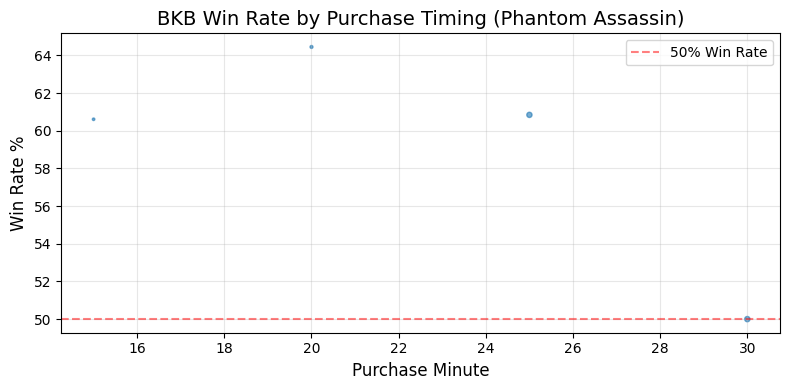

In [0]:
if not isinstance(result, str) and not result.empty:
    plt.figure(figsize=(8, 4))
    plt.scatter(result['time'], result['win_rate'], s=result['games']/10, alpha=0.6)
    plt.xlabel('Purchase Minute', fontsize=12)
    plt.ylabel('Win Rate %', fontsize=12)
    plt.title('BKB Win Rate by Purchase Timing (Phantom Assassin)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=50, color='r', linestyle='--', alpha=0.5, label='50% Win Rate')
    plt.legend()
    plt.tight_layout()
    display(plt.show())

In [0]:
midgame_advice(
    my_hero="Phantom Assassin",
    enemy_hero="Invoker",
    my_item="black_king_bar",
    heroes_df=heroes_df,
    matchups_df=matchups_df
)

Mid game decision for: Phantom Assassin vs Invoker
Match up Base Win Rate: Phantom Assassin has a 47.2% win rate against Invoker.
Under 50% WR, rush core items.
Best Timing Window: Minute 20 (64.4% WR)


## Run ur own example

In [0]:
my_hero = "Phantom Assassin"
enemy = "Axe"
item = "desolator"

midgame_advice(
    my_hero=my_hero,
    enemy_hero=enemy,
    my_item=item,
    heroes_df=heroes_df,
    matchups_df=matchups_df
)

Mid game decision for: Phantom Assassin vs Axe
Match up Base Win Rate: Phantom Assassin has a 48.8% win rate against Axe.
Best Timing Window: Minute 20 (68.9% WR)
